#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import * 

In [2]:
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

dataset = 'Cr-Co-W' # 'Fe-Mo'#
system=dataset.replace('-','')
from BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()
PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{system}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

# Prepare Extra features

In [3]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [4]:
Features = Featurizer(BS)

In [5]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [6]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [7]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [8]:
MagneticFeature = Features.Mag
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [9]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [10]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/1688 [00:00<?, ?it/s]

In [11]:
CNList

Cr_pv10Co_pv14.C36-BABBA.FM         [16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 16, 1...
Co_pv14W_sv16.sigma-AABBA.FM        [12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1...
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM     [16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1...
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM     [16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1...
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM     [16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1...
                                                          ...                        
Cr_pv13Co_pv16.chi-ABAB.FM          [16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1...
Cr_pv2W_sv11.mu-BBABB.FM            [15, 15, 12, 12, 12, 12, 12, 12, 12, 16, 16, 1...
Cr_pv20Co_pv4.C36-BAAAA.FM          [16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 1...
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM    [16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1...
Co_pv10W_sv20.sigma-ABBBA.FM        [12, 12, 14, 14, 14, 14, 14, 14, 14, 14, 15, 1...
Length: 1688, dtype: object

## Position Features

In [12]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [13]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [14]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [15]:
from mendeleev import element

In [16]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [17]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [18]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [19]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [20]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

# Matminer Features 

In [21]:
from Tools.DatasetTools.GetPymatgenFeatures import *

In [22]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [23]:
BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition:   0%|          | 0/1688 [00:00<?, ?it/s]

In [24]:
BS['atoms_objects'] = PymatgenStructures

In [25]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAPFeatures = load_features(mmfstructure, BS, which='soap')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [26]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,...,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,24.888033,67.545024,42.656991,46.796871,13.469168,47.210308,49.340640,56.893957,7.553318,52.784263,...,1.297120,0.500880,0.424421,0.468761,199.453199,228.771919,29.318720,217.678651,9.593162,217.077607
std,4.915760,16.218144,16.660144,15.777415,8.411207,24.016275,0.988113,2.580996,2.673854,2.107945,...,0.571162,0.442980,0.275953,0.711636,12.697248,2.817002,12.909941,10.012658,6.237355,16.592269
min,24.000000,24.000000,0.000000,24.000000,0.000000,24.000000,49.000000,49.000000,0.000000,49.000000,...,0.000000,0.000000,0.000000,0.000000,194.000000,194.000000,0.000000,194.000000,0.000000,194.000000
25%,24.000000,74.000000,47.000000,33.333333,5.902222,27.000000,49.000000,58.000000,7.000000,51.137255,...,1.548471,0.122248,0.190731,0.000000,194.000000,229.000000,35.000000,212.666667,4.311074,194.000000
50%,24.000000,74.000000,50.000000,44.704244,13.638889,27.000000,49.000000,58.000000,9.000000,52.166667,...,1.548471,0.387118,0.430131,0.000000,194.000000,229.000000,35.000000,220.250000,9.722222,229.000000
75%,24.000000,74.000000,50.000000,62.461538,21.555556,74.000000,49.000000,58.000000,9.000000,53.877321,...,1.548471,0.722620,0.688209,1.548471,194.000000,229.000000,35.000000,226.236842,15.555556,229.000000
max,74.000000,74.000000,50.000000,74.000000,24.793388,74.000000,58.000000,58.000000,9.000000,58.000000,...,1.548471,1.548471,0.774236,1.548471,229.000000,229.000000,35.000000,229.000000,17.500000,229.000000


In [27]:
DensitiFeatures.dropna(axis=1, inplace=True)
if DensitiFeatures.shape[1] > 0:
    DensitiFeatures.describe()

In [28]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,-0.208048,-0.207001,0.001046,4.186505,0.092097,0.012673,2.559834,0.753776,0.711642,0.691372,0.686156,0.683515
std,0.049699,0.050574,0.006029,0.145786,0.039349,0.008008,0.542206,0.136913,0.168051,0.186172,0.191571,0.194524
min,-0.322368,-0.322368,0.000000,3.716833,0.000000,0.000000,1.000000,0.584998,0.493242,0.435713,0.416972,0.406636
25%,-0.220603,-0.220603,0.000000,4.080115,0.055973,0.005229,2.000000,0.628932,0.563224,0.530175,0.509580,0.500861
50%,-0.220603,-0.220603,0.000000,4.199398,0.115294,0.013709,3.000000,0.707107,0.673540,0.651528,0.646555,0.645325
75%,-0.181413,-0.181413,0.000000,4.302260,0.115294,0.019364,3.000000,0.885748,0.877995,0.877202,0.877193,0.877193
max,-0.118123,-0.118123,0.054052,4.397803,0.115294,0.028585,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Pyscal features 

In [29]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [30]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

##  Coordination Numbers

In [31]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [32]:
PyscalFeatures

,pyscal_steinhardt_0,pyscal_steinhardt_1,pyscal_cn
Cr_pv10Co_pv14.C36-BABBA.FM,"[0.0053385417813247935, 0.005338541781324821, ...","[0.1942883561066591, 0.19428835610665907, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 16, 1..."
Co_pv14W_sv16.sigma-AABBA.FM,"[0.09617556302880145, 0.09617556302880122, 0.0...","[0.645723632201294, 0.6457236322012941, 0.3158...","[12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 1..."
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,"[0.011022436115045518, 0.011022436115045569, 0...","[0.19197958595047768, 0.19197958595047768, 0.1...","[16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1..."
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,"[0.0053385417813247935, 0.005338541781324706, ...","[0.1942883561066591, 0.19428835610665904, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 16, 16, 16, 1..."
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,"[0.011022436115045572, 0.011022436115045456, 0...","[0.1919795859504777, 0.1919795859504777, 0.191...","[16, 16, 16, 16, 12, 12, 12, 12, 16, 16, 16, 1..."
...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,"[0.03160847926125844, 0.07272265497611828, 0.0...","[0.19382539926827577, 0.451909678646869, 0.451...","[16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1..."
Cr_pv2W_sv11.mu-BBABB.FM,"[0.0016125060908427345, 0.0016125060908423706,...","[0.29326918583364187, 0.29326918583364175, 0.6...","[15, 15, 12, 12, 12, 12, 12, 12, 12, 16, 16, 1..."
Cr_pv20Co_pv4.C36-BAAAA.FM,"[0.00533854178132472, 0.005338541781324761, 0....","[0.1942883561066591, 0.19428835610665912, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 1..."
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,"[0.005338541781324651, 0.0053385417813247545, ...","[0.1942883561066591, 0.19428835610665904, 0.19...","[16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 1..."


## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [33]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [34]:
intersect = thisFeatures.index.intersection(CNList.index)

In [35]:
CNPyscal  = gf.featurize_many(thisFeatures.loc[intersect], CNList[intersect], [gf.cn_average])

  0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
CNPyscal

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN13,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN13,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Cr_pv10Co_pv14.C36-BABBA.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Co_pv14W_sv16.sigma-AABBA.FM,0.063293,0.037974,0.000000,0.022234,0.003085,0.000000,0.469031,0.209215,0.000000,0.217703,0.042113,0.000000
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM,0.028944,0.021523,0.000000,0.000000,0.000000,0.007421,0.502143,0.360095,0.000000,0.000000,0.000000,0.142048
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM,0.028944,0.020576,0.000000,0.000000,0.000000,0.008368,0.502143,0.360479,0.000000,0.000000,0.000000,0.141663
...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv13Co_pv16.chi-ABAB.FM,0.081875,0.046632,0.030092,0.000000,0.000000,0.005151,0.471315,0.250462,0.186997,0.000000,0.000000,0.033856
Cr_pv2W_sv11.mu-BBABB.FM,0.043541,0.036474,0.000000,0.004550,0.000248,0.002268,0.478648,0.340808,0.000000,0.061350,0.045118,0.031371
Cr_pv20Co_pv4.C36-BAAAA.FM,0.028944,0.026217,0.000000,0.000000,0.000000,0.002727,0.502143,0.437765,0.000000,0.000000,0.000000,0.064378
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM,0.028944,0.021523,0.000000,0.000000,0.000000,0.007421,0.502143,0.360095,0.000000,0.000000,0.000000,0.142048


In [37]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [38]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Features 

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

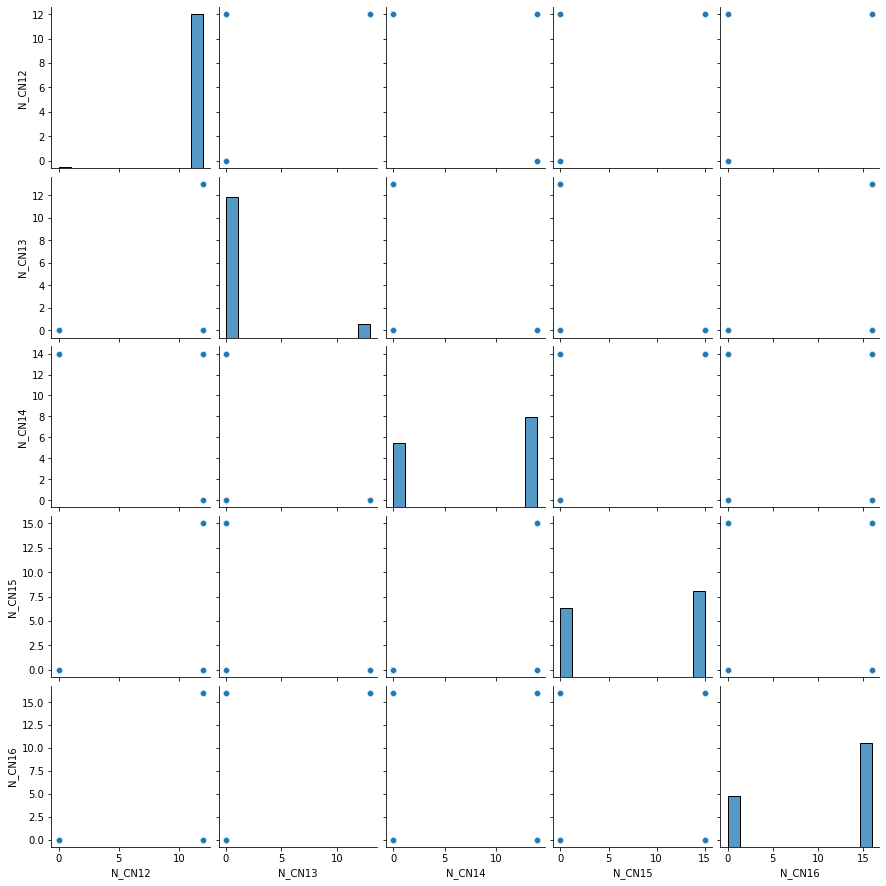

In [40]:
sns.pairplot(CN)

##  Correlations

In [41]:
plt.rc('font',size=22)

In [42]:
BS['EF'] = BS['EF'].astype(float)

In [43]:
FeatureGroups = {'density features': DensitiFeatures, 'atomic features': AtomicFeaturesMagpie, 'composition features': CompositionFeatures, 'Dataset Features': DatasetFeatures}
TargetCorrelations = {groupname: GroupFeatures.corrwith(BS['EF']).abs().dropna().sort_values(ascending=False) for groupname, GroupFeatures in FeatureGroups.items()}

In [44]:
len(TargetCorrelations)

4

[None]

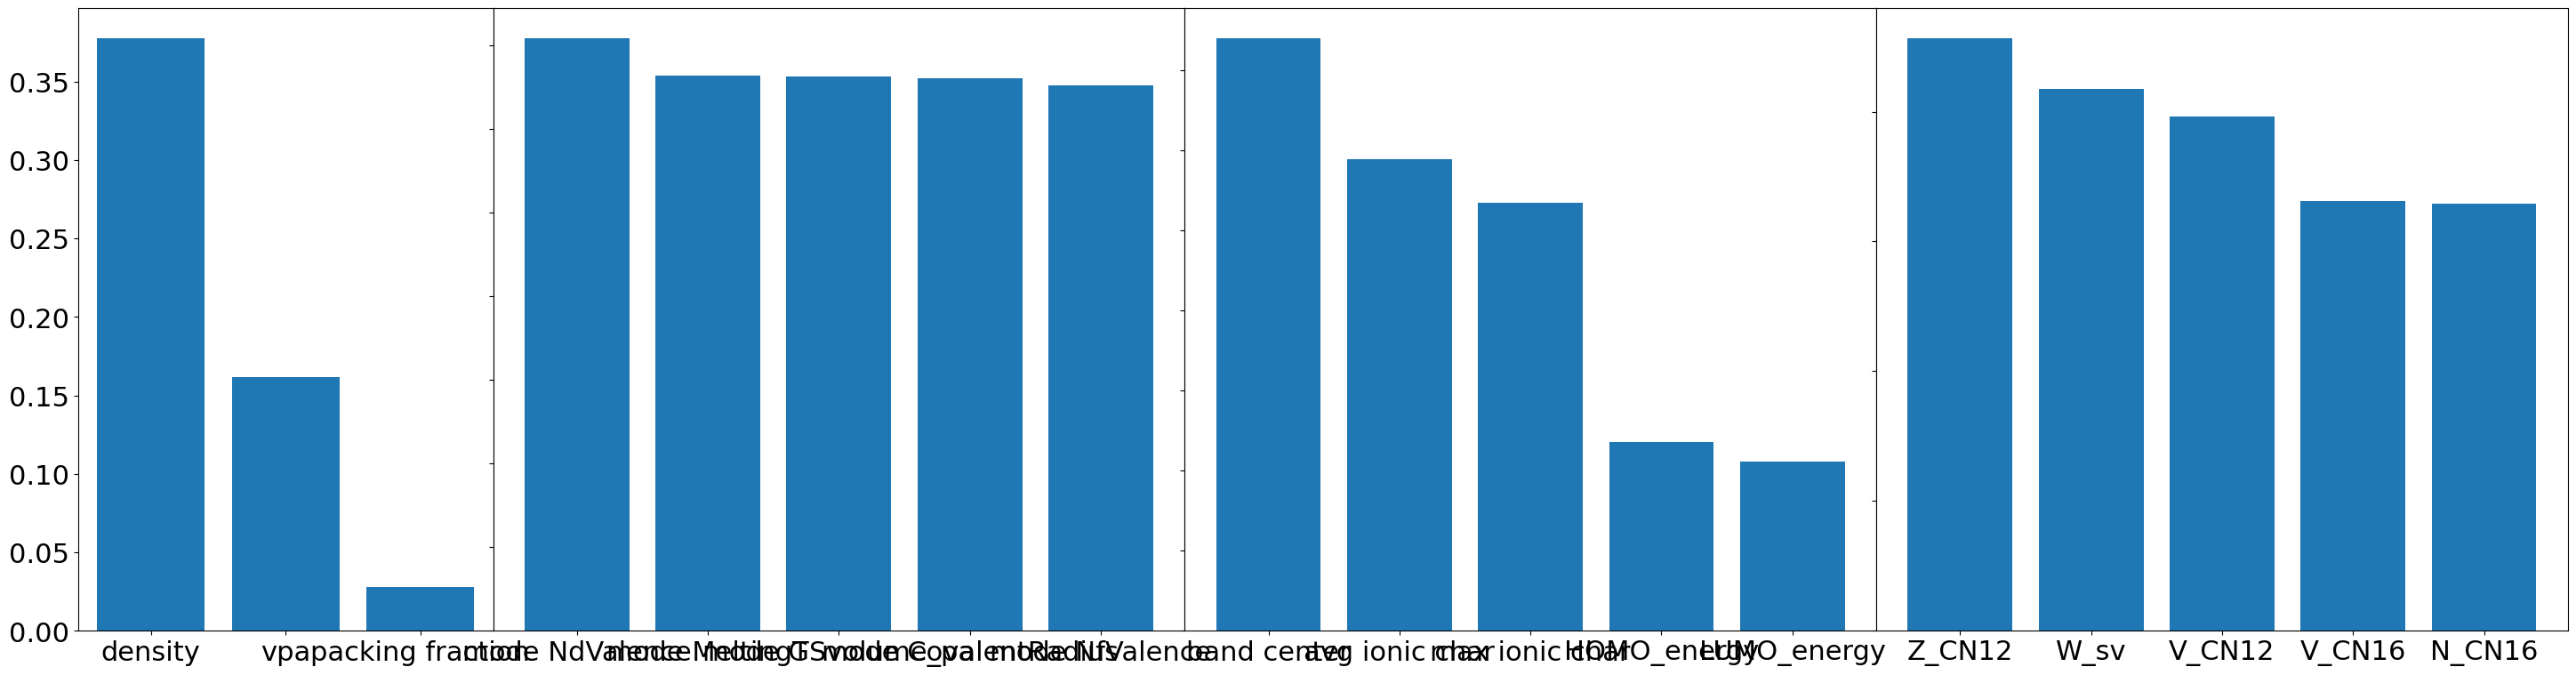

In [45]:
fig = plt.figure(figsize=(len(TargetCorrelations)*7, 10))
border=0
totalfeatures=18
for i, (group, TargetCorr) in enumerate(TargetCorrelations.items()):
    nfeatures = len(TargetCorr[:5])
    ax = fig.add_axes([border/totalfeatures,0.2,(nfeatures)/totalfeatures,0.7])
    border +=nfeatures
    ax.bar( TargetCorr[:5].index,TargetCorr[:5].values) #, ax = ax, orient='vertical')
axes = fig.get_axes()
[tax.set_yticklabels(tax.get_yticklabels(), visible=False) for tax in axes[1:]]
[tax.sharey(axes[0]) for tax in axes[:1]]
#axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90) 

# Plot correlations for most correlated

In [62]:
for name, item in DensitiFeatures.iteritems():
    print(name)

density
vpa
packing fraction


In [63]:
DensitiFeatures[DensitiFeatures.vpa < 6]

,density,vpa,packing fraction
index,,,
W_sv1.fcc.FM,118.483858,2.576499,4.0


<AxesSubplot:xlabel='vpa', ylabel='Count'>

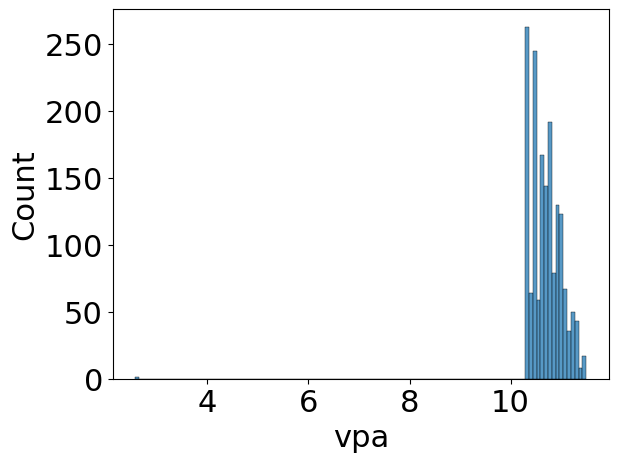

In [64]:
sns.histplot(DensitiFeatures.vpa)

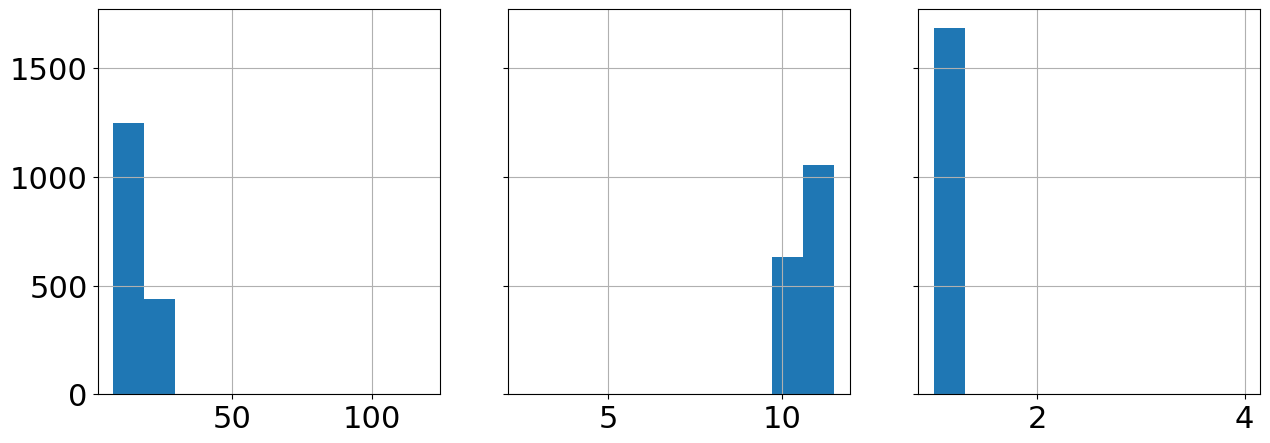

In [65]:
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(15,5))
for (fname, feature), ax in zip(DensitiFeatures.iteritems(), axes):
    feature.hist(ax=ax)
#    sns.histplot(feature, ax =ax)

## By hand outlier detection:

In [66]:
selection = (FeatureGroups['density features']['packing fraction'] < 3) & (FeatureGroups['density features']['vpa']>8) &(FeatureGroups['density features']['density']<75)

In [67]:
def target_correlation_scatters(thisgroup, selection=None):
    featurenames = TargetCorrelations[thisgroup].index.to_list()
    if selection is None:
        selection = FeatureGroups[thisgroup].index
    nplots =  min([4, len(featurenames)])
    fig, axes = plt.subplots(1, nplots,  figsize=(7*4, 10), sharey=True)
    intersect = selection.intersection(BS['EF'].index)
    for ax, thisfeature in zip(axes, featurenames[:nplots]):
        ax.scatter(FeatureGroups[thisgroup][thisfeature][intersect], BS['EF'][intersect])
        ax.set_xlabel(thisfeature)
    axes[0].set_ylabel('$\Delta E_f$')

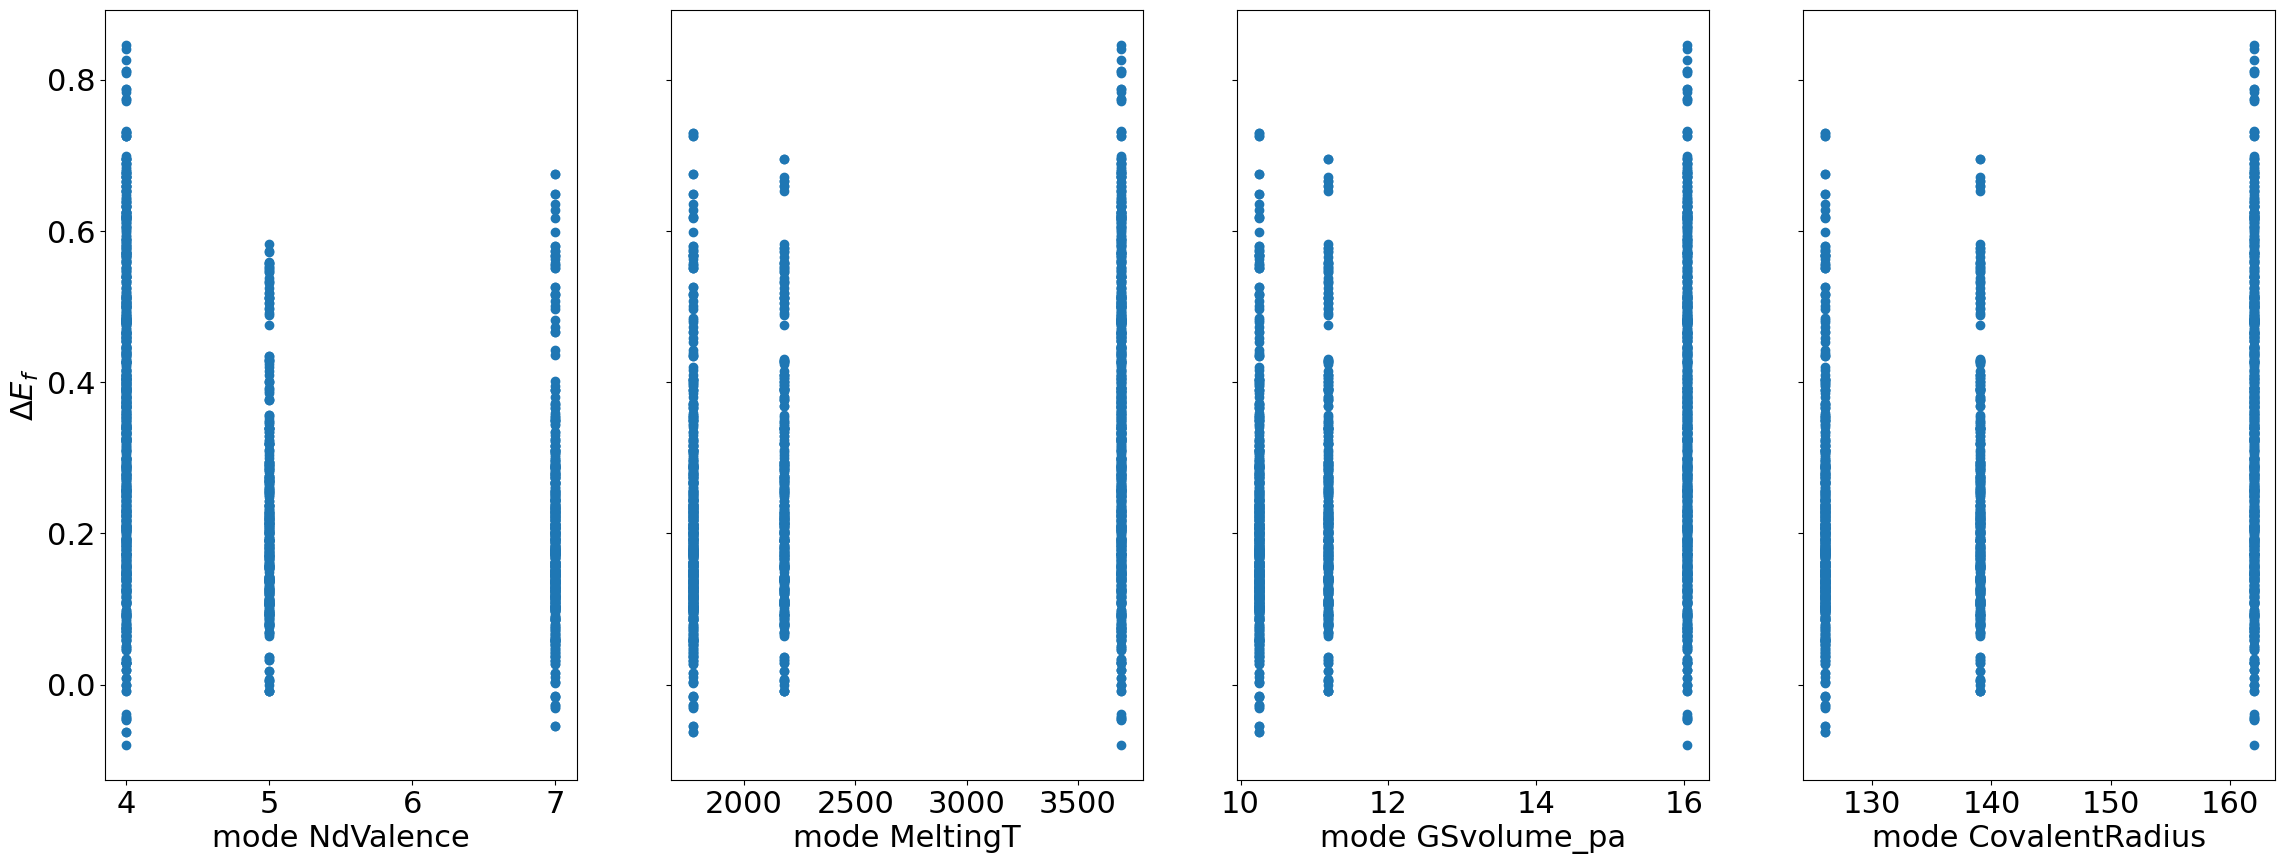

In [68]:
target_correlation_scatters('atomic features')

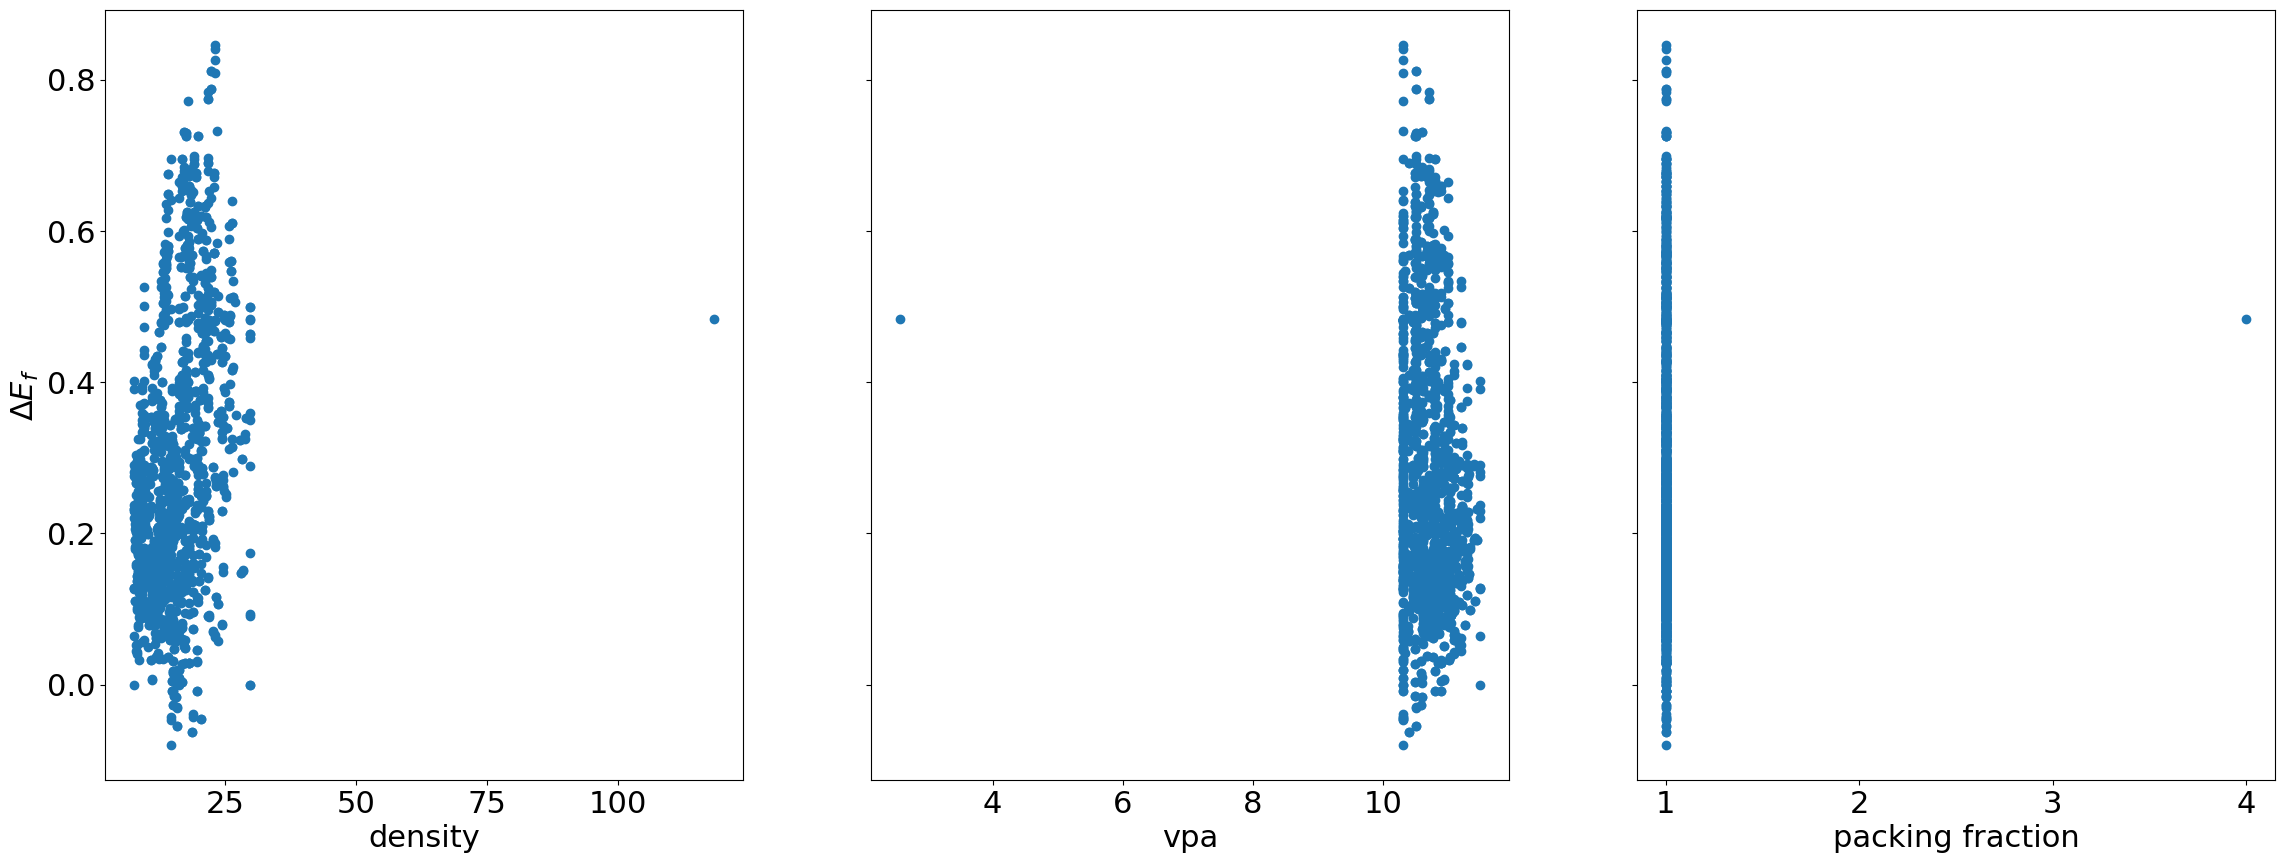

In [69]:
target_correlation_scatters('density features')#, selection=selection)

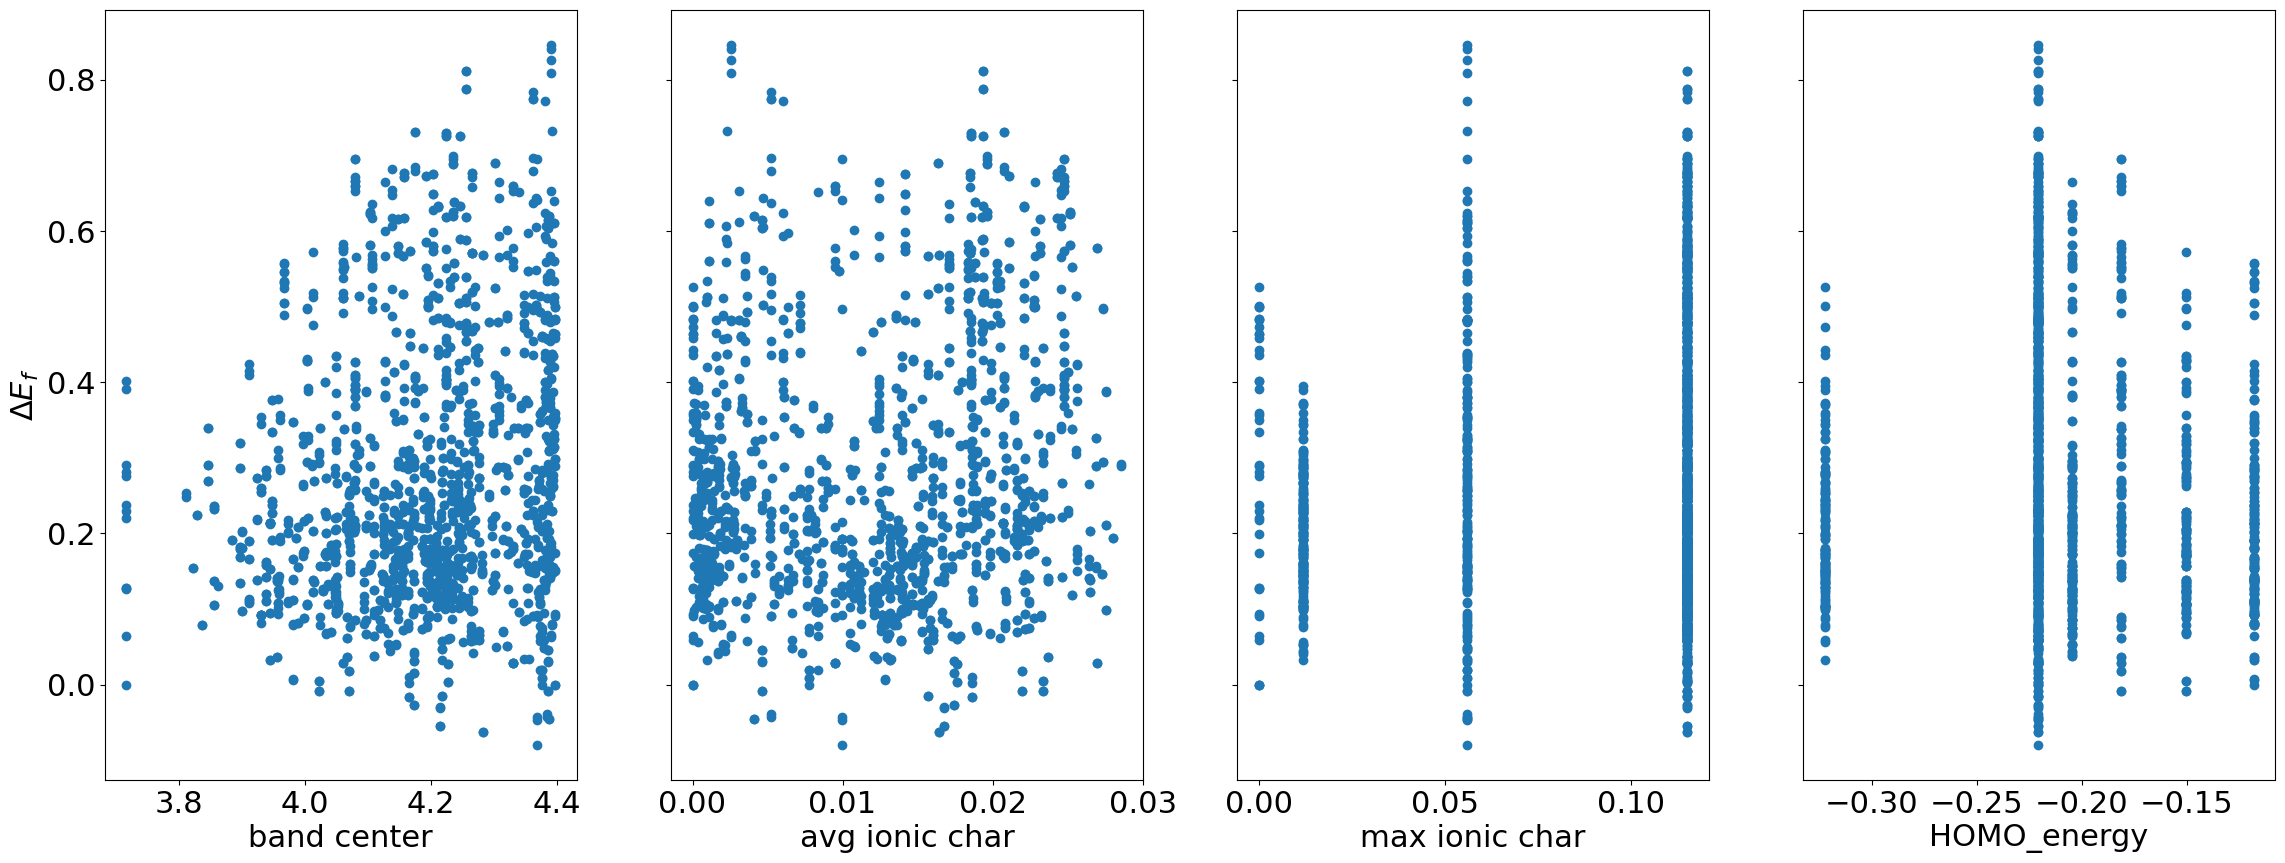

In [70]:
target_correlation_scatters('composition features')

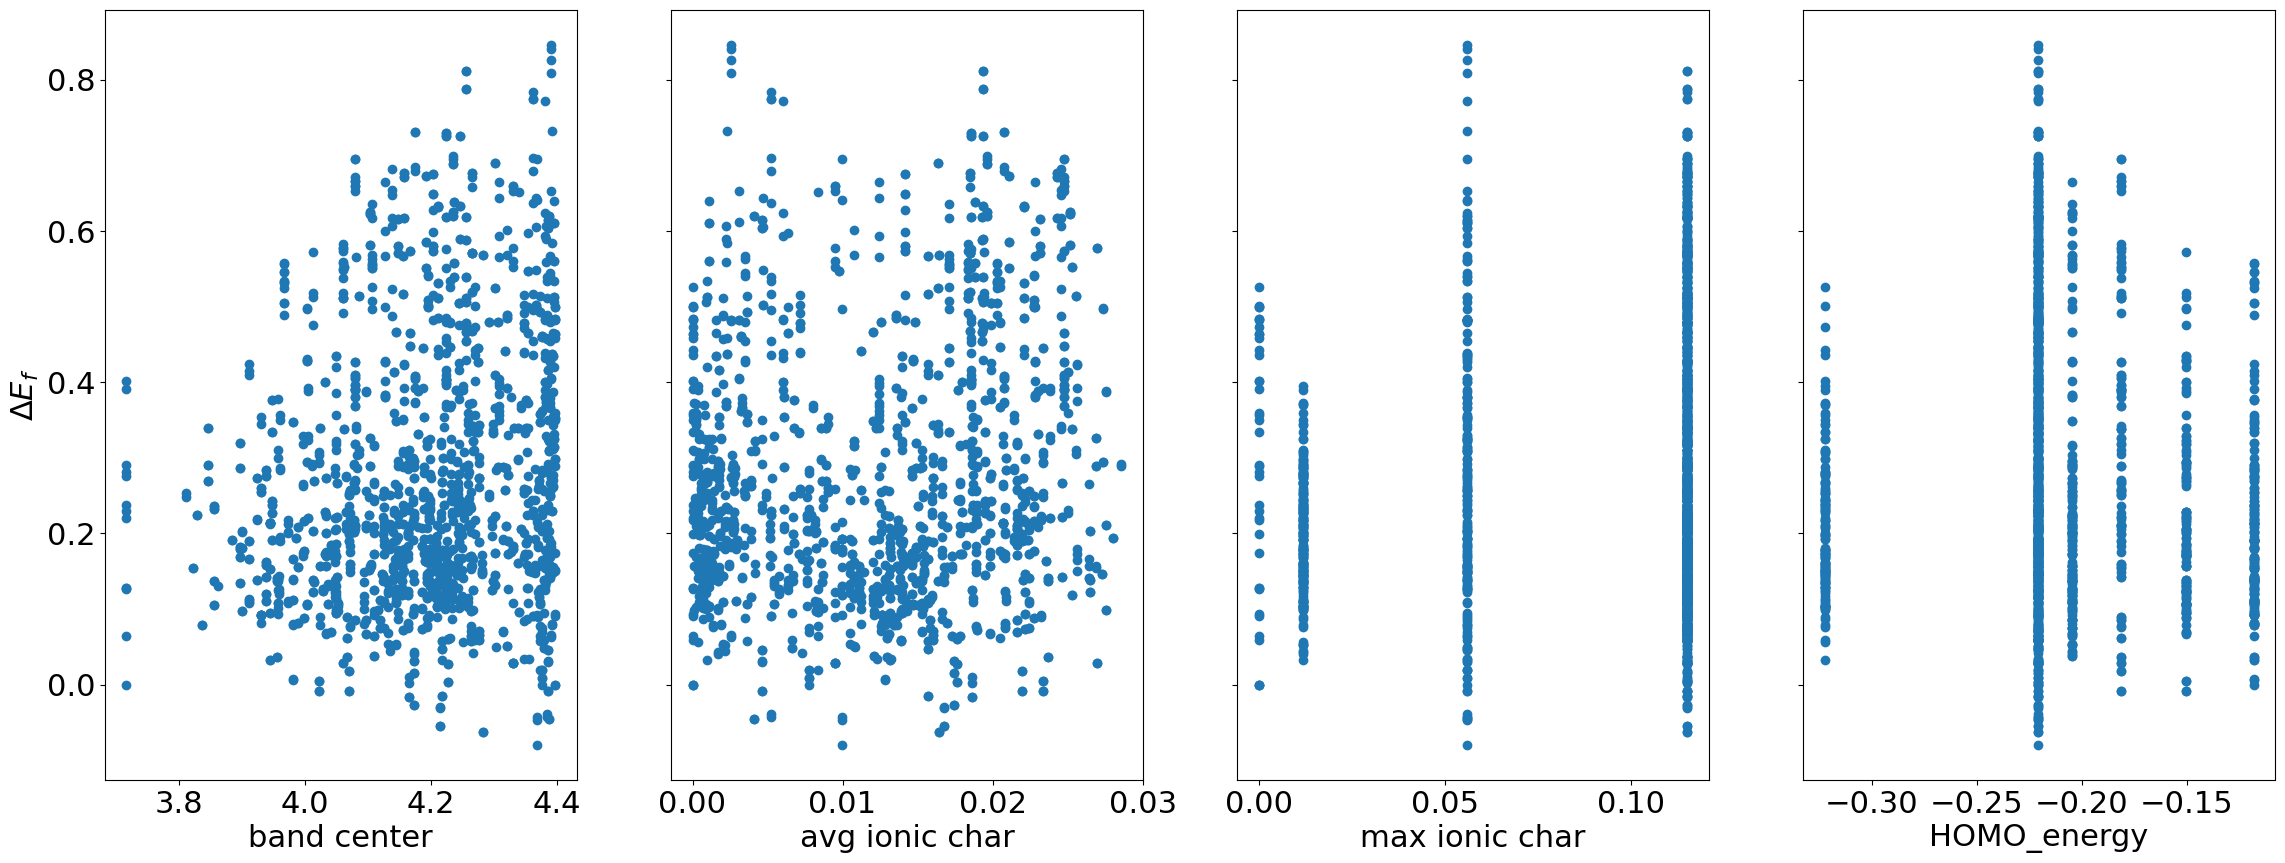

In [71]:
target_correlation_scatters('composition features')

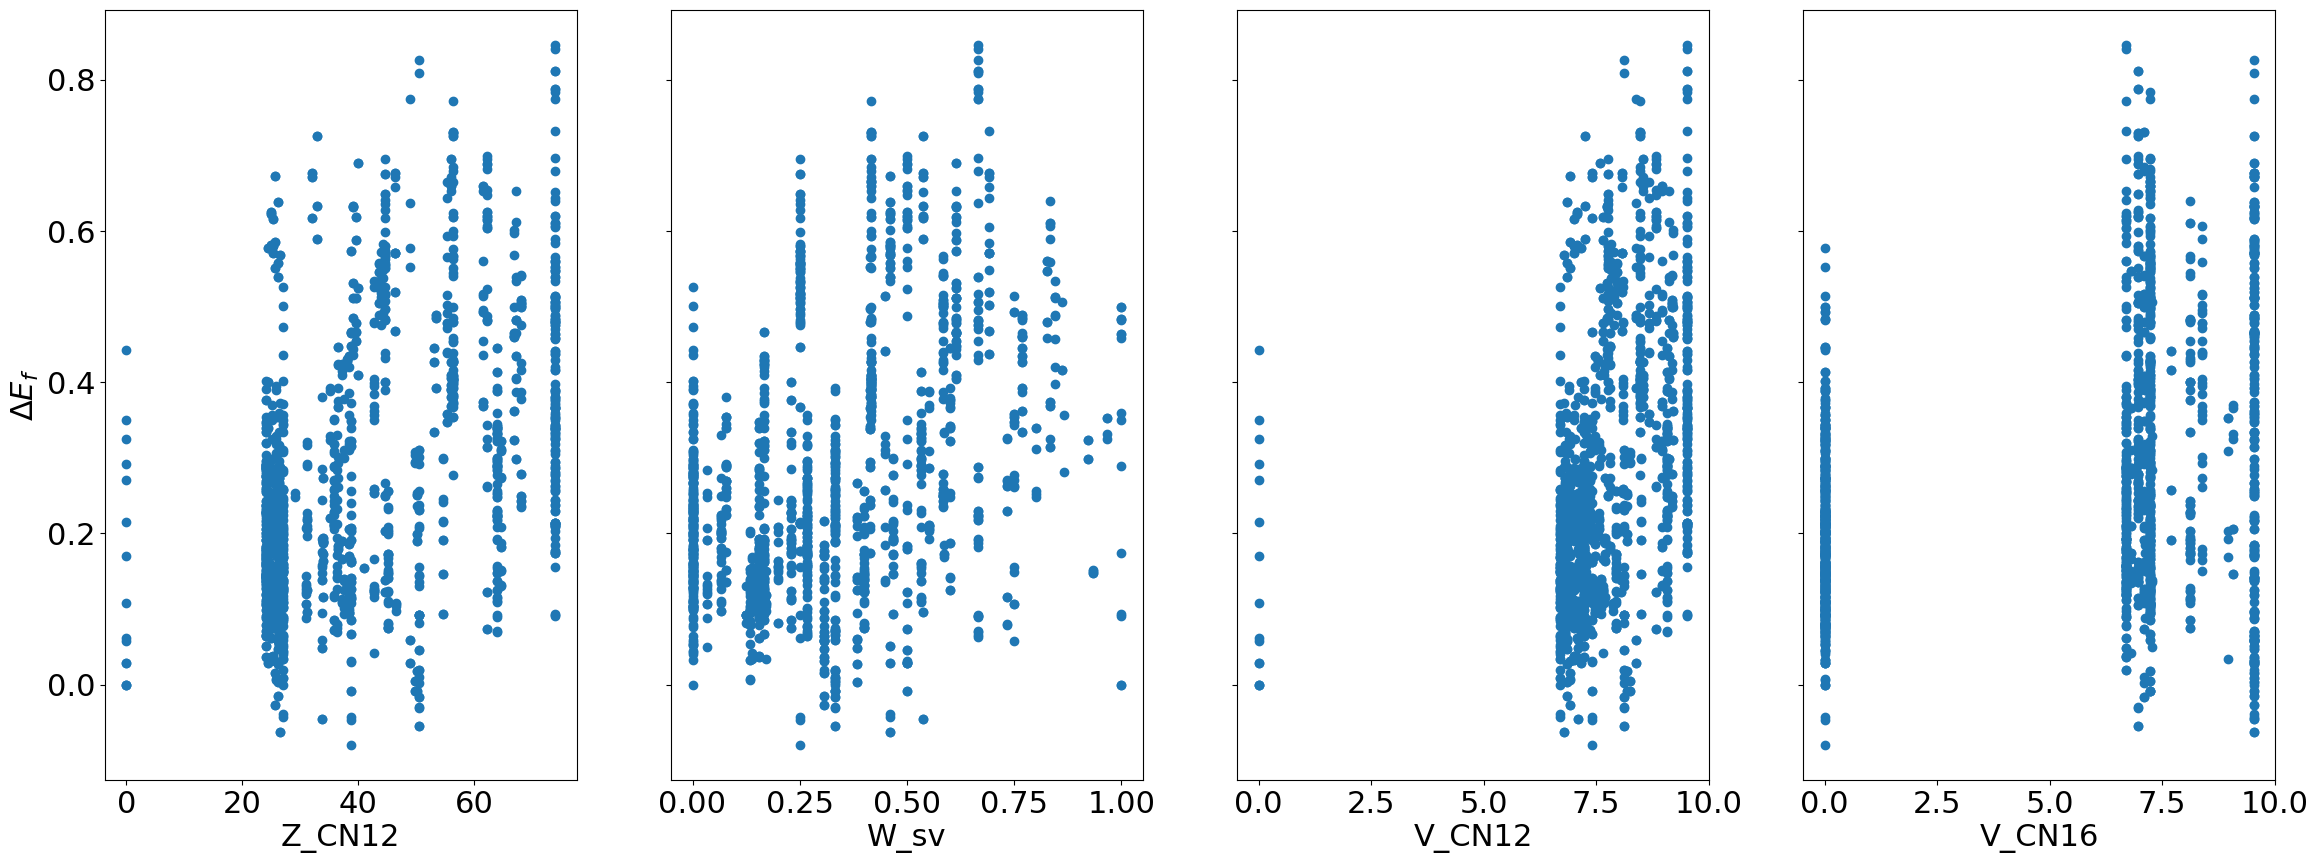

In [72]:
target_correlation_scatters('Dataset Features')

In [73]:
TargetCorrelations.keys()

dict_keys(['density features', 'atomic features', 'composition features', 'Dataset Features'])